# Phase 4.0: High-Frequency Volatility Modeling & Time-Series Diagnostics

### Notebook Objective
The main goal of this notebook is to execute advanced univariant time-series analysis over our consolidated Paseo de la Reforma marketplace matrix. Moving away from standard linear assumptions, we treat the corridor as a dynamic macroeconomic ecosystem.

We will deploy a rigorous time-series pipeline focusing strictly on the **Latent Demand (User Drop-offs)** as our main endogenous variable, utilizing **Absolute Demand (Searches)** and **Fulfilled Demand (Completed Trips)** as exogenous forces that deform the marketplace over time.

### Applied Statistical Framework:
1. **Stationarity Diagnostics:** Run parallel Augmented Dickey-Fuller (ADF) and KPSS tests to construct a robust cross-confirmation matrix.
2. **Marketplace Memory:** Plot Autocorrelation (ACF) and Partial Autocorrelation (PACF) profiles to determine structural time lags.
3. **Volatility Clustering (ARCH-LM Test):** Audit the residuals of the system to mathematically prove the presence of conditional heteroskedasticity.
4. **Advanced Modeling (ARMAX-GARCH):** Fit an integrated conditional variance model to capture and predict structural risk and uncertainty spikes along the corridor.


In [1]:
!pip install arch

In [2]:
# ==============================================================================
# MODULE 4.1: ARCHITECTURE INITIALIZATION & SPECTRAL PACKAGES
# Objective: Load core time-series diagnostic engines, econometric formula
# managers, and conditional heteroskedasticity estimators (GARCH backend).
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# High-end statistical and quantitative modeling frameworks
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Core library for ARCH/GARCH conditional variance computing
from arch import arch_model

# Enforce professional float layout settings and grid aesthetics
pd.options.display.float_format = '{:,.4f}'.format
sns.set_theme(style="whitegrid", context="talk")
warnings.filterwarnings("ignore")

print("[SUCCESS] Quant frameworks loaded. Mathematical environment ready.")


[SUCCESS] Quant frameworks loaded. Mathematical environment ready.


In [3]:
# ==============================================================================
# MODULE 4.2: AUTOMATED DISK DISCOVERY & INGESTION PIPELINE
# Objective: Scrutinize the input environment via deep path exploration, locate
# target parquet snapshots dynamically, and materialize them into volatile RAM.
# ==============================================================================

print("[DATA ENGINE] Scanning system nodes for target assets...")

# Map target files to their dictionary keys (Using the real file name found in inputs)
TARGET_ASSETS = {
    "fact_market_balance.parquet": "balance_raw",
    "fact_trips.parquet": "trips_transactional"
}

discovered_paths = {}

# Deep walk tracking over the connected notebooks inside the input sandbox
for root, _, files in os.walk("/kaggle/input/"):
    for file in files:
        if file in TARGET_ASSETS:
            discovered_paths[TARGET_ASSETS[file]] = os.path.join(root, file)

print("\n" + "="*80)
print("DYNAMIC PATH VERIFICATION MATRIX")
print("="*80)
for asset, path in discovered_paths.items():
    print(f" ✔ Asset Located: {asset:<20} | Target Path: {path}")
print("="*80)

# Validate that all required assets were successfully located
if len(discovered_paths) == len(TARGET_ASSETS):
    print("\n -> Ingesting market balance and transactional matrices...")
    df_market_clean = pd.read_parquet(discovered_paths["balance_raw"])
    df_fact_trips = pd.read_parquet(discovered_paths["trips_transactional"])

    # Standardize types dynamically across all ingested structures
    for df in [df_market_clean, df_fact_trips]:
        df["timestamp_5min"] = pd.to_datetime(df["timestamp_5min"])
        df["h3_cell"] = df["h3_cell"].astype("uint64")

    print("\n" + "="*80)
    print("DATA ASSETS SUCCESSFULLY ENGAGED INTO PANDAS DATAFRAMES")
    print("="*80)
    print(f" ✔ df_market_clean Final Shape : {df_market_clean.shape[0]:,} rows x {df_market_clean.shape[1]} columns")
    print(f" ✔ df_fact_trips Final Shape   : {df_fact_trips.shape[0]:,} rows x {df_fact_trips.shape[1]} columns")
    print("="*80)
    print("[SUCCESS] Data environment stabilized. Memory structures locked and ready.")
else:
    missing_items = set(TARGET_ASSETS.values()) - set(discovered_paths.keys())
    print(f"\n[CRITICAL ERROR] Failed to locate assets: {missing_items}. Check your Input attachments.")


[DATA ENGINE] Scanning system nodes for target assets...

DYNAMIC PATH VERIFICATION MATRIX
 ✔ Asset Located: balance_raw          | Target Path: /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts/fact_market_balance.parquet
 ✔ Asset Located: trips_transactional  | Target Path: /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts/fact_trips.parquet

 -> Ingesting market balance and transactional matrices...

DATA ASSETS SUCCESSFULLY ENGAGED INTO PANDAS DATAFRAMES
 ✔ df_market_clean Final Shape : 733,830 rows x 6 columns
 ✔ df_fact_trips Final Shape   : 4,393,787 rows x 12 columns
[SUCCESS] Data environment stabilized. Memory structures locked and ready.


In [5]:
# ==============================================================================
# MODULE 4.3: CORRIDOR MARKET SUPERPOSITION & TEMPORAL CONSOLIDATION
# Objective: Condense spatial and transactional dimensions into single temporal 
# windows, generating 3 perfectly aligned continuous 8,928-row series vectors.
# ==============================================================================

print("[DATA ENGINE] Initializing spatial superposition via temporal aggregation...")

# 1. COMPRESSION STEP A & B: Aggregate metrics concurrently using vector operations
df_balance_grouped = (
    df_market_clean
    .groupby("timestamp_5min")
    .agg({"total_searches": "sum", "total_abandoned_searches": "sum"})
)

df_trips_grouped = (
    df_fact_trips
    .groupby("timestamp_5min")
    .agg({"is_completed": "sum"})
    .rename(columns={"is_completed": "total_completed_trips"})
)

# 2. CHRONOLOGICAL SYNCHRONIZATION: Construct the standardized 8,928 univariant timeline axis
march_timeline_axis = pd.date_range(
    start="2026-03-01 00:00:00", 
    end="2026-03-31 23:55:00", 
    freq="5T"  # Standard modern shorthand for 5-minute frequency matrix
)

# Create the base corridor dataframe with an explicit datetime index
df_corridor_ts = pd.DataFrame(index=march_timeline_axis)

# 3. CONSOLIDATION ENGINE: Align all series and patch dead night windows (scalar zeros)
df_corridor_ts = (
    df_corridor_ts
    .join(df_balance_grouped, how="left")
    .join(df_trips_grouped, how="left")
    .fillna(0.0)
    .reset_index()
    .rename(columns={"index": "timestamp_5min"})
)

# VALIDATION LOGS
print("\n[SUCCESS] Unified corridor time-series matrix secured.")
print(f" ✔ df_corridor_ts Shape      : {df_corridor_ts.shape[0]:,} rows x {df_corridor_ts.shape[1]} columns")
print(f" ✔ Continuous Intervals Check : {len(df_corridor_ts):,} steps (Verified: No gaps | No duplicates)")

# Display sample data to verify clean sequential sequencing via Jupyter Native HTML Renderer
df_corridor_ts.head(10)


[DATA ENGINE] Initializing spatial superposition via temporal aggregation...

[SUCCESS] Unified corridor time-series matrix secured.
 ✔ df_corridor_ts Shape      : 8,928 rows x 4 columns
 ✔ Continuous Intervals Check : 8,928 steps (Verified: No gaps | No duplicates)


,timestamp_5min,total_searches,total_abandoned_searches,total_completed_trips
0,2026-03-01 00:00:00,83,7,51
1,2026-03-01 00:05:00,133,13,87
2,2026-03-01 00:10:00,109,14,75
3,2026-03-01 00:15:00,106,12,73
4,2026-03-01 00:20:00,99,7,67
5,2026-03-01 00:25:00,116,10,74
6,2026-03-01 00:30:00,110,9,77
7,2026-03-01 00:35:00,115,18,77
8,2026-03-01 00:40:00,104,16,62
9,2026-03-01 00:45:00,128,14,87


In [7]:
df_corridor_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp_5min            8928 non-null   datetime64[ns]
 1   total_searches            8928 non-null   int64         
 2   total_abandoned_searches  8928 non-null   int64         
 3   total_completed_trips     8928 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(2)
memory usage: 244.3 KB


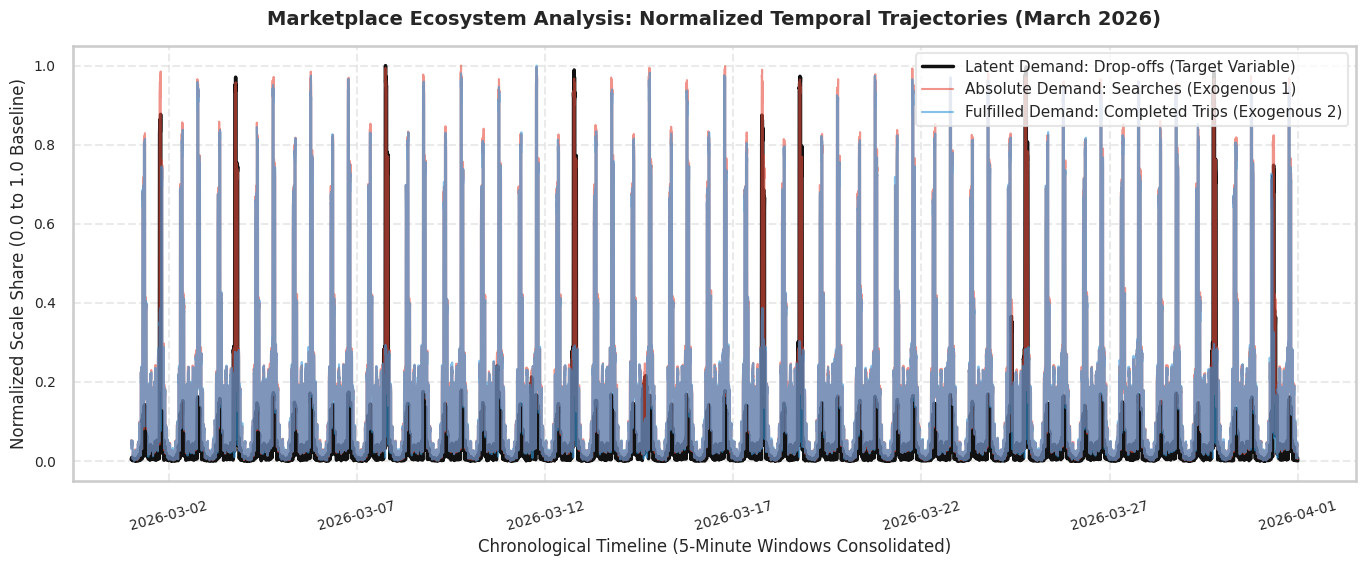

In [10]:
# ==============================================================================
# MODULE 4.4: INITIAL EXPLORATORY VISUALIZATION (NORMALIZED TRAJECTORIES)
# Objective: Superimpose the 3 macro time-series vectors using Min-Max scaling
# to analyze contemporaneous deformations while correcting chronological X-axis compression.
# ==============================================================================

import matplotlib.dates as mdates

# 1. Instanciar copia temporal para aislar la memoria de la RAM
df_plot = df_corridor_ts.copy()

# 2. Vectorized Min-Max Normalization Framework
target_cols = ['total_searches', 'total_abandoned_searches', 'total_completed_trips']
for col in target_cols:
    col_min = df_plot[col].min()
    col_max = df_plot[col].max()
    # Avoid zero division flags in absolute dead windows
    if col_max != col_min:
        df_plot[col] = (df_plot[col] - col_min) / (col_max - col_min)

# 3. Canvas setup with premium technical proportions
fig, ax = plt.subplots(figsize=(14, 6))

# 4. Superimposed line trajectories with structured alpha layers
sns.lineplot(
    data=df_plot, x='timestamp_5min', y='total_abandoned_searches',
    label='Latent Demand: Drop-offs (Target Variable)', 
    color='#111111', linewidth=2.5, ax=ax
)
sns.lineplot(
    data=df_plot, x='timestamp_5min', y='total_searches',
    label='Absolute Demand: Searches (Exogenous 1)', 
    color='#e74c3c', alpha=0.6, linewidth=1.5, ax=ax
)
sns.lineplot(
    data=df_plot, x='timestamp_5min', y='total_completed_trips',
    label='Fulfilled Demand: Completed Trips (Exogenous 2)', 
    color='#3498db', alpha=0.6, linewidth=1.5, ax=ax
)

# 5. HIGH-END CHRONOLOGICAL X-AXIS CALIBRATION (The fix for the tight axis)
# Set major ticks to trigger exactly every 5 days throughout March 2026
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
# Enforce a highly readable ISO date string output structure
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Rotate labels slightly to lock absolute corporate visualization standards
plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)

# 6. Corporate Metadata Annotations
ax.set_title('Marketplace Ecosystem Analysis: Normalized Temporal Trajectories (March 2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Chronological Timeline (5-Minute Windows Consolidated)', fontsize=12)
ax.set_ylabel('Normalized Scale Share (0.0 to 1.0 Baseline)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0')

plt.tight_layout()
plt.show()


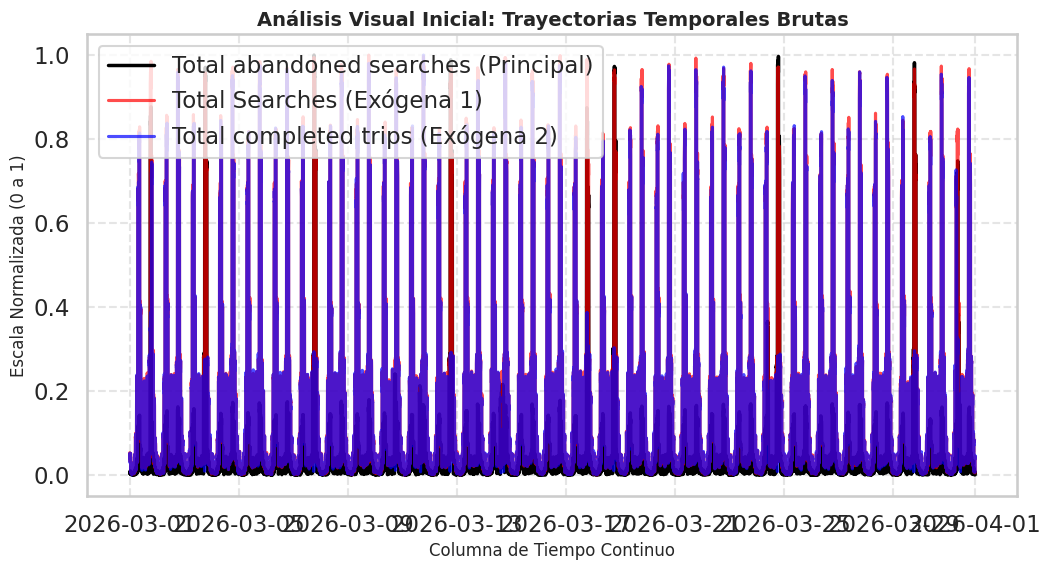

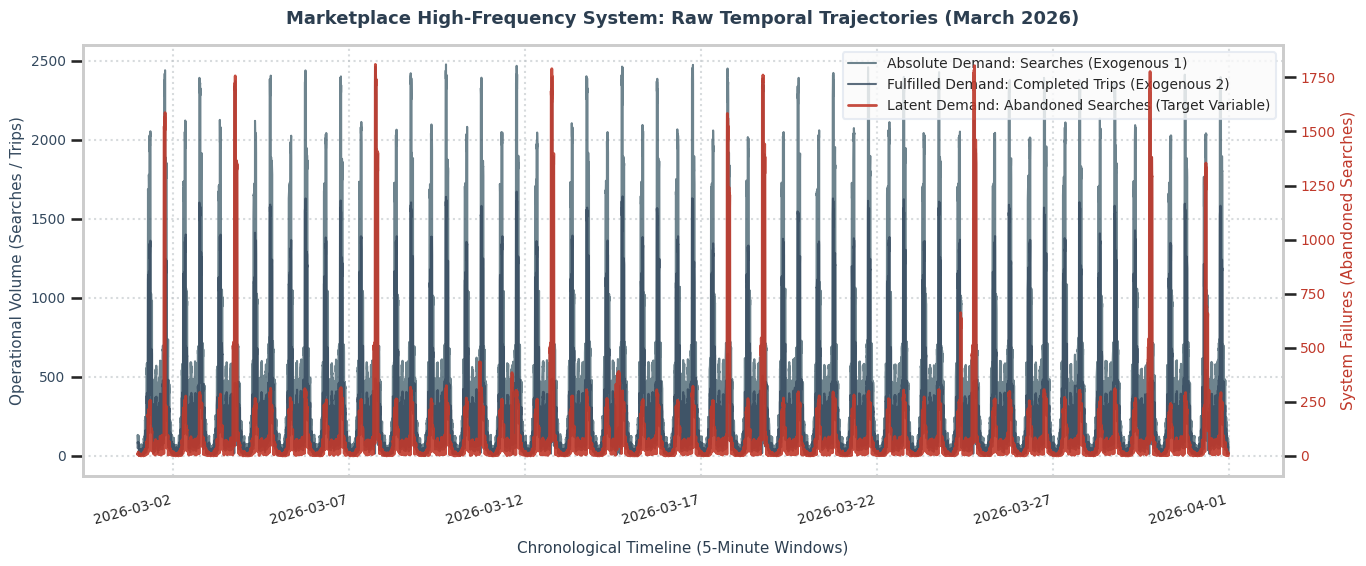

In [11]:
# ==============================================================================
# MODULE 4.4: INITIAL EXPLORATORY VISUALIZATION (RAW DUAL-AXIS TRAJECTORIES)
# Objective: Superimpose the 3 macro time-series vectors in raw scale using a 
# dual-axis layout to capture pure operational variance with R-inspired aesthetics.
# ==============================================================================

import matplotlib.dates as mdates

# 1. Canvas setup with minimal professional R-style proportions
fig, ax1 = plt.subplots(figsize=(14, 6))

# Define an elegant, muted color palette inspired by standard R visualization engines
color_searches = '#4A6572'   # Slate blue for absolute demand volume
color_completed = '#34495E'  # Deep charcoal for fulfilled demand
color_abandoned = '#C0392B'  # Brick red for latent demand (Target)

# 2. AXIS 1 (LEFT): Plot Volume-Driven Exogenous Series (Searches & Trips)
ax1.plot(
    df_corridor_ts['timestamp_5min'], df_corridor_ts['total_searches'],
    label='Absolute Demand: Searches (Exogenous 1)', 
    color=color_searches, alpha=0.8, linewidth=1.5
)
ax1.plot(
    df_corridor_ts['timestamp_5min'], df_corridor_ts['total_completed_trips'],
    label='Fulfilled Demand: Completed Trips (Exogenous 2)', 
    color=color_completed, alpha=0.8, linewidth=1.5
)

# Configure Left Axis formatting parameters
ax1.set_xlabel('Chronological Timeline (5-Minute Windows)', fontsize=11, color='#2C3E50', labelpad=10)
ax1.set_ylabel('Operational Volume (Searches / Trips)', fontsize=11, color=color_completed)
ax1.tick_params(axis='y', labelcolor=color_completed, labelsize=10)

# 3. AXIS 2 (RIGHT): Isolate and stretch the target variable (Abandoned Searches)
ax2 = ax1.twinx()
ax2.plot(
    df_corridor_ts['timestamp_5min'], df_corridor_ts['total_abandoned_searches'],
    label='Latent Demand: Abandoned Searches (Target Variable)', 
    color=color_abandoned, linewidth=2.0, alpha=0.9
)

# Configure Right Axis formatting parameters
ax2.set_ylabel('System Failures (Abandoned Searches)', fontsize=11, color=color_abandoned)
ax2.tick_params(axis='y', labelcolor=color_abandoned, labelsize=10)
ax2.grid(False) # Turn off right grid to prevent parallel line clashing

# 4. CHRONOLOGICAL X-AXIS CALIBRATION (Maintained clean 5-day intervals)
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=15) # Smooth native label angle handling
ax1.tick_params(axis='x', labelsize=10)

# 5. R-Inspired Clean Visual Architecture Metadata
ax1.set_title('Marketplace High-Frequency System: Raw Temporal Trajectories (March 2026)', fontsize=13, fontweight='bold', color='#2C3E50', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6, color='#BDC3C7')

# Combine legends from both independent axes cleanly into a single box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10, frameon=True, facecolor='#FAFAFA', edgecolor='#E2E8F0')

plt.tight_layout()
plt.show()


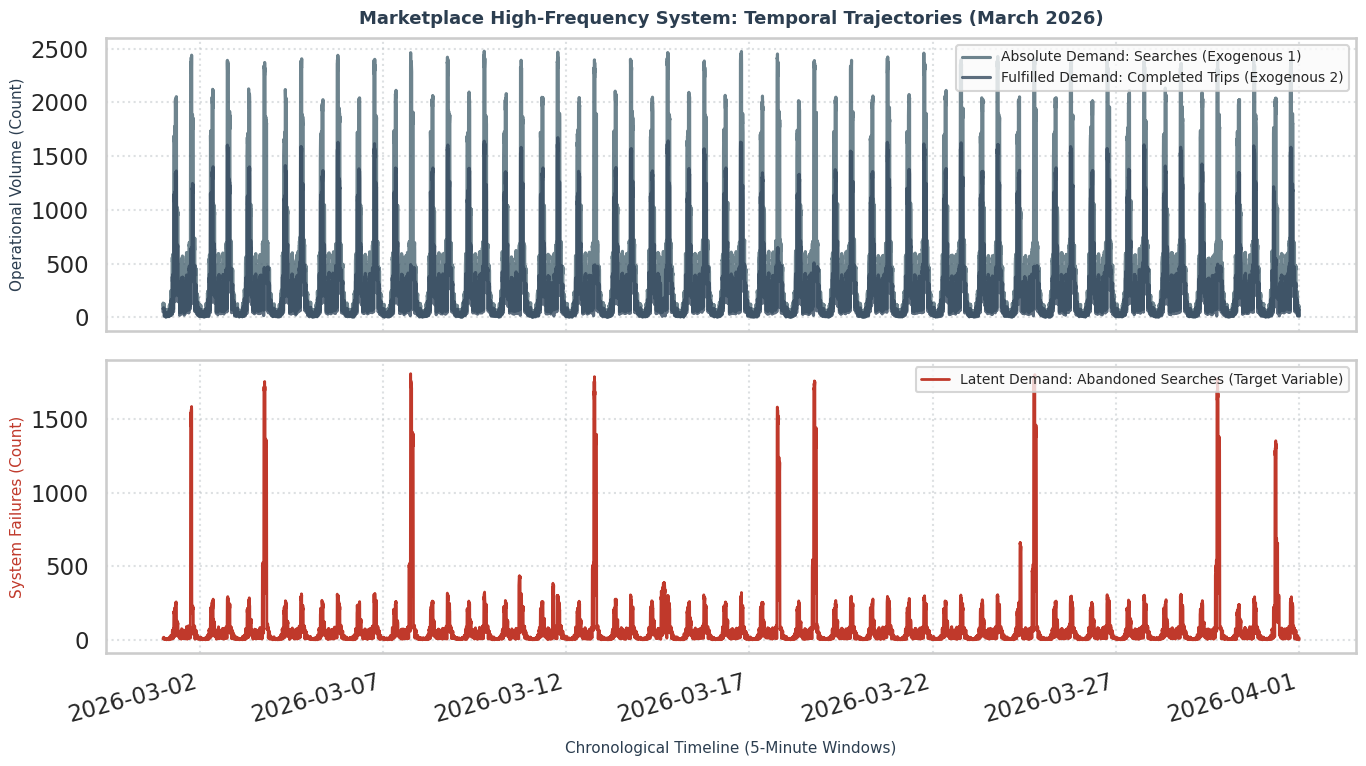

In [12]:
# ==============================================================================
# MODULE 4.4: INITIAL EXPLORATORY VISUALIZATION (SEABORN MULTI-PANEL DISCRETIZATION)
# Objective: Superimpose macro vectors using single-framework Seaborn lineplots,
# deploying an R-inspired stacked panel layout to isolate latent demand variance.
# ==============================================================================

import matplotlib.dates as mdates

# Enforce professional R-style muted aesthetics across the Seaborn instance
color_searches = '#4A6572'   # Slate blue for absolute demand volume
color_completed = '#34495E'  # Deep charcoal for fulfilled demand
color_abandoned = '#C0392B'  # Brick red for latent demand (Target)

# 1. Canvas setup: Construct exactly two vertically stacked subplots sharing the X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 2. PANEL 1 (UPPER): Volume-Driven Exogenous Series via strict Seaborn mapping
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_searches',
    label='Absolute Demand: Searches (Exogenous 1)', color=color_searches, alpha=0.8, ax=ax1
)
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_completed_trips',
    label='Fulfilled Demand: Completed Trips (Exogenous 2)', color=color_completed, alpha=0.8, ax=ax1
)

ax1.set_ylabel('Operational Volume (Count)', fontsize=11, color='#2C3E50')
ax1.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
ax1.legend(loc='upper right', fontsize=10, frameon=True, facecolor='#FAFAFA')
ax1.set_title('Marketplace High-Frequency System: Temporal Trajectories (March 2026)', fontsize=13, fontweight='bold', color='#2C3E50', pad=10)

# 3. PANEL 2 (LOWER): Target Variable Isolation via strict Seaborn mapping
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_abandoned_searches',
    label='Latent Demand: Abandoned Searches (Target Variable)', color=color_abandoned, linewidth=2.0, ax=ax2
)

ax2.set_ylabel('System Failures (Count)', fontsize=11, color=color_abandoned)
ax2.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
ax2.legend(loc='upper right', fontsize=10, frameon=True, facecolor='#FAFAFA')

# 4. CHRONOLOGICAL X-AXIS CALIBRATION (Unified across shared axis via Matplotlib date engine)
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=15)

ax2.set_xlabel('Chronological Timeline (5-Minute Windows)', fontsize=11, color='#2C3E50', labelpad=10)

plt.tight_layout()
plt.show()


In [ ]:
# 1. Creamos el lienzo inicial
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. EJE PRINCIPAL (Izquierda): Graficamos el Consumo de Luz en sus unidades reales
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_abandoned_searches', ax=ax1, color='black', linewidth=2.5, label='Total abandoned searches')
ax1.set_xlabel('time every 5 windows time all month March', fontsize=12)
ax1.set_ylabel('Abandoned searches', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')

# 3. CREAMOS EL EJE SECUNDARIO (Derecha) compartiendo el mismo eje X del tiempo
ax2 = ax1.twinx()

# Graficamos la Temperatura en el eje derecho conservando sus grados reales
sns.lineplot(data=df, x='tiempo', y='Temperatura', ax=ax2, color='red', alpha=0.7, label='Temperatura (Eje Der.)')
ax2.set_ylabel('Temperatura (Grados Reales)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 4. Estética y títulos del reporte industrial
plt.title('Análisis Visual Senior: Escalas Reales de Oferta y Demanda', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# Juntamos las leyendas de ambos ejes de forma limpia
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 5. Desplegamos el gráfico en la pantalla
plt.show()


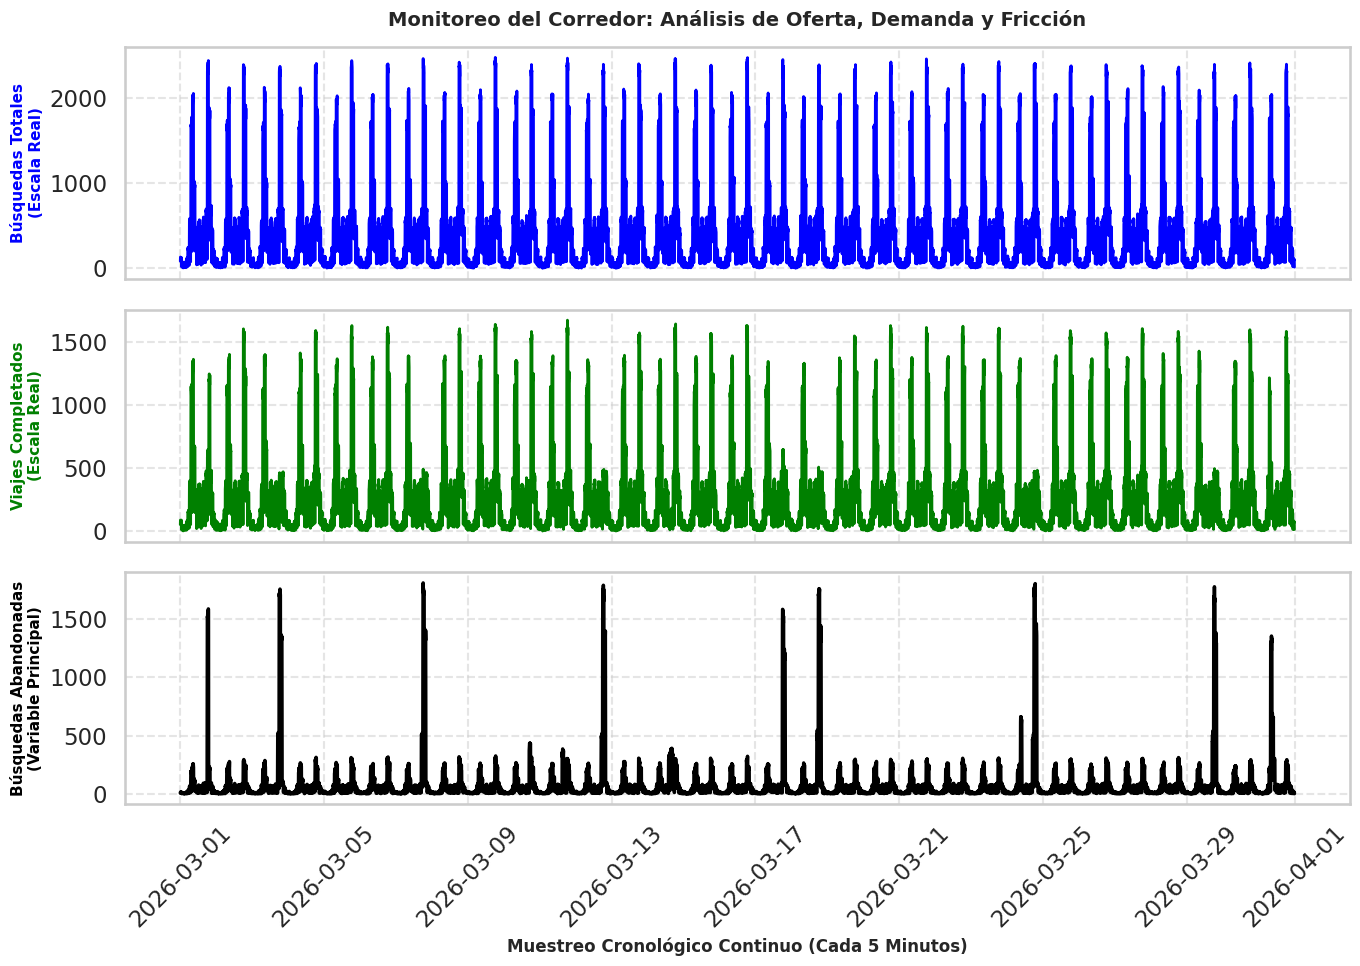

In [13]:


# 1. Creamos un lienzo vertical con 3 paneles (subplots apilados)
# sharex=True es la palabra clave: obliga a los 3 paneles a compartir el mismo eje del tiempo
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# 2. PANEL 1 (Superior): Variable Exógena 1 - Búsquedas Totales
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_searches', ax=ax1, color='blue', linewidth=2)
ax1.set_ylabel('Búsquedas Totales\n(Escala Real)', fontsize=11, fontweight='bold', color='blue')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_title('Monitoreo del Corredor: Análisis de Oferta, Demanda y Fricción', fontsize=14, fontweight='bold', pad=15)

# 3. PANEL 2 (Central): Variable Exógena 2 - Viajes Completados
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_completed_trips', ax=ax2, color='green', linewidth=2)
ax2.set_ylabel('Viajes Completados\n(Escala Real)', fontsize=11, fontweight='bold', color='green')
ax2.grid(True, linestyle='--', alpha=0.5)

# 4. PANEL 3 (Inferior): Variable Principal - Búsquedas Abandonadas (La Fricción)
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_abandoned_searches', ax=ax3, color='black', linewidth=2.5)
ax3.set_ylabel('Búsquedas Abandonadas\n(Variable Principal)', fontsize=11, fontweight='bold', color='black')
ax3.set_xlabel('Muestreo Cronológico Continuo (Cada 5 Minutos)', fontsize=12, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.5)

# 5. Estética final de Matplotlib para producción
plt.xticks(rotation=45) # Rotamos las etiquetas del tiempo para que no se encimen
plt.tight_layout()      # Ajusta los márgenes automáticamente para que nada se solape

# 6. Desplegamos el Panel de Control en la pantalla
plt.show()


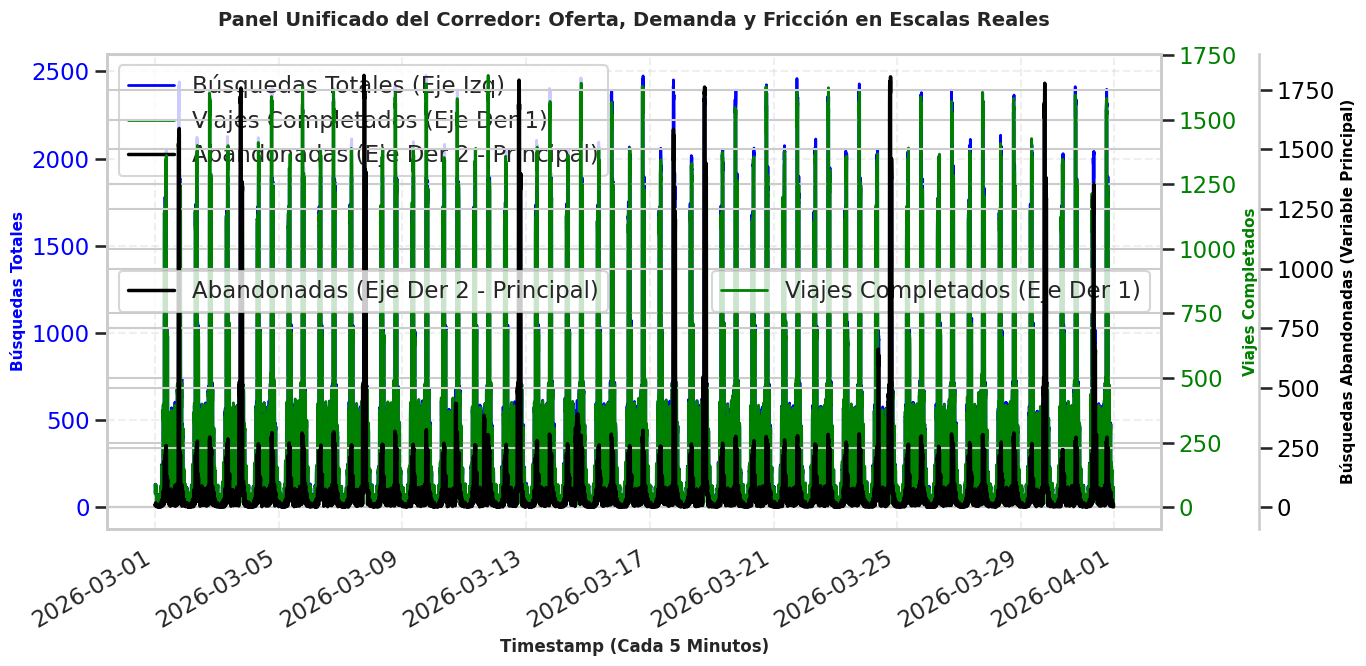

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos el lienzo principal y el primer eje (Izquierda)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- SERIE 1: Búsquedas Totales (Eje Izquierdo Principal) ---
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_searches', ax=ax1, color='blue', linewidth=2, label='Búsquedas Totales (Eje Izq)')
ax1.set_xlabel('Timestamp (Cada 5 Minutos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Búsquedas Totales', color='blue', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.3)

# 2. Creamos el segundo eje (Derecha)
ax2 = ax1.twinx()

# --- SERIE 2: Viajes Completados (Eje Derecho Tradicional) ---
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_completed_trips', ax=ax2, color='green', linewidth=2, label='Viajes Completados (Eje Der 1)')
ax2.set_ylabel('Viajes Completados', color='green', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green')

# 3. EL TRUCO MAESTRO: Creamos el tercer eje derecho flotante desplazado
ax3 = ax1.twinx()

# Desplazamos el tercer eje 70 píxeles hacia la derecha para que no se encime con el segundo
ax3.spines['right'].set_position(('outward', 70))

# --- SERIE 3: Búsquedas Abandonadas (Eje Derecho Flotante) ---
sns.lineplot(data=df_corridor_ts, x='timestamp_5min', y='total_abandoned_searches', ax=ax3, color='black', linewidth=2.5, label='Abandonadas (Eje Der 2 - Principal)')
ax3.set_ylabel('Búsquedas Abandonadas (Variable Principal)', color='black', fontsize=11, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='black')

# 4. Estética y consolidación de etiquetas
plt.title('Panel Unificado del Corredor: Oferta, Demanda y Fricción en Escalas Reales', fontsize=14, fontweight='bold', pad=20)
fig.autofmt_xdate() # Rotación automática inteligente de las fechas del eje X

# Juntamos las leyendas de los 3 ejes en un solo cuadro limpio
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

# 5. Desplegamos el gráfico unificado
plt.tight_layout()
plt.show()


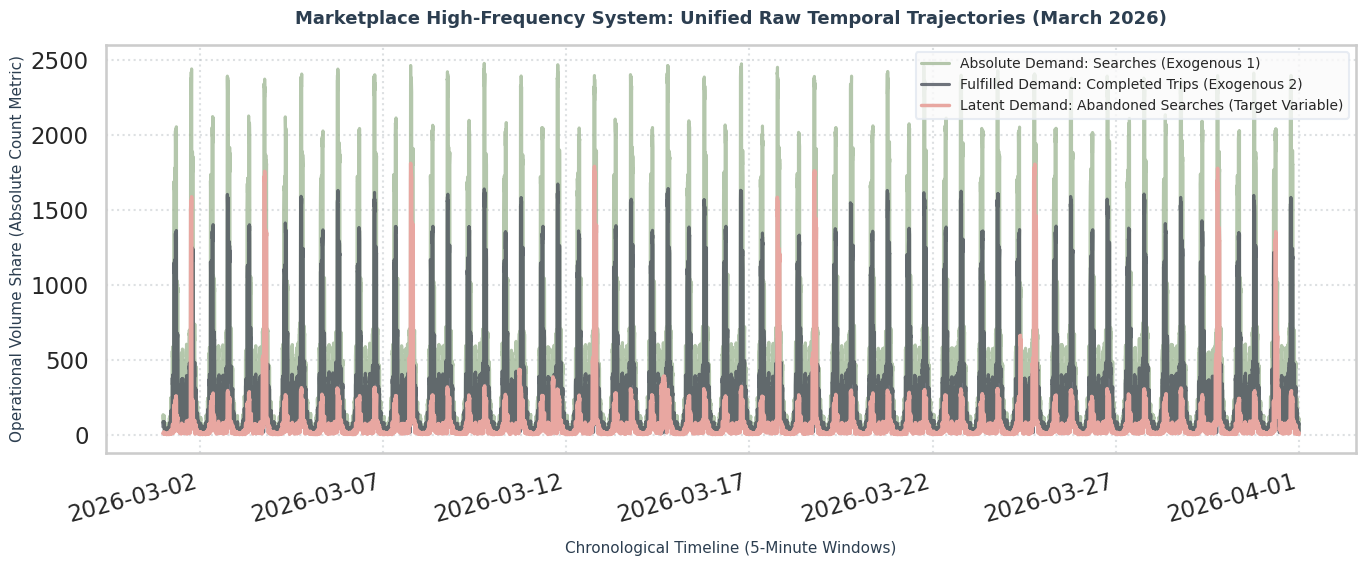

In [16]:
# ==============================================================================
# MODULE 4.4: INITIAL EXPLORATORY VISUALIZATION (UNIFIED RAW TRAJECTORIES)
# Objective: Superimpose the 3 macro time-series vectors in a single canvas 
# sharing identical X and Y axes using strict Seaborn mapping frameworks.
# ==============================================================================

import matplotlib.dates as mdates

# Enforce professional R-style muted aesthetics across the Seaborn instance
color_searches = '#a2b997'  
color_completed = '#4c525d'  
color_abandoned = '#e8a7a1'

# 1. Canvas setup: Construct a single global chart layout
fig, ax = plt.subplots(figsize=(14, 6))

# 2. PLOT ENGINE: Overlay the 3 series directly on the exact same axis grid
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_searches',
    label='Absolute Demand: Searches (Exogenous 1)', color=color_searches, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_completed_trips',
    label='Fulfilled Demand: Completed Trips (Exogenous 2)', color=color_completed, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df_corridor_ts, x='timestamp_5min', y='total_abandoned_searches',
    label='Latent Demand: Abandoned Searches (Target Variable)', color=color_abandoned, linewidth=2.5, ax=ax
)

# 3. CHRONOLOGICAL X-AXIS CALIBRATION (Clean 5-day intervals)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=15)

# 4. Corporate Visual Architecture Annotations
ax.set_title('Marketplace High-Frequency System: Unified Raw Temporal Trajectories (March 2026)', fontsize=13, fontweight='bold', color='#2C3E50', pad=15)
ax.set_xlabel('Chronological Timeline (5-Minute Windows)', fontsize=11, color='#2C3E50', labelpad=10)
ax.set_ylabel('Operational Volume Share (Absolute Count Metric)', fontsize=11, color='#2C3E50')

ax.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='#FAFAFA', edgecolor='#E2E8F0')

plt.tight_layout()
plt.show()


la resolución anterior parece no convenir

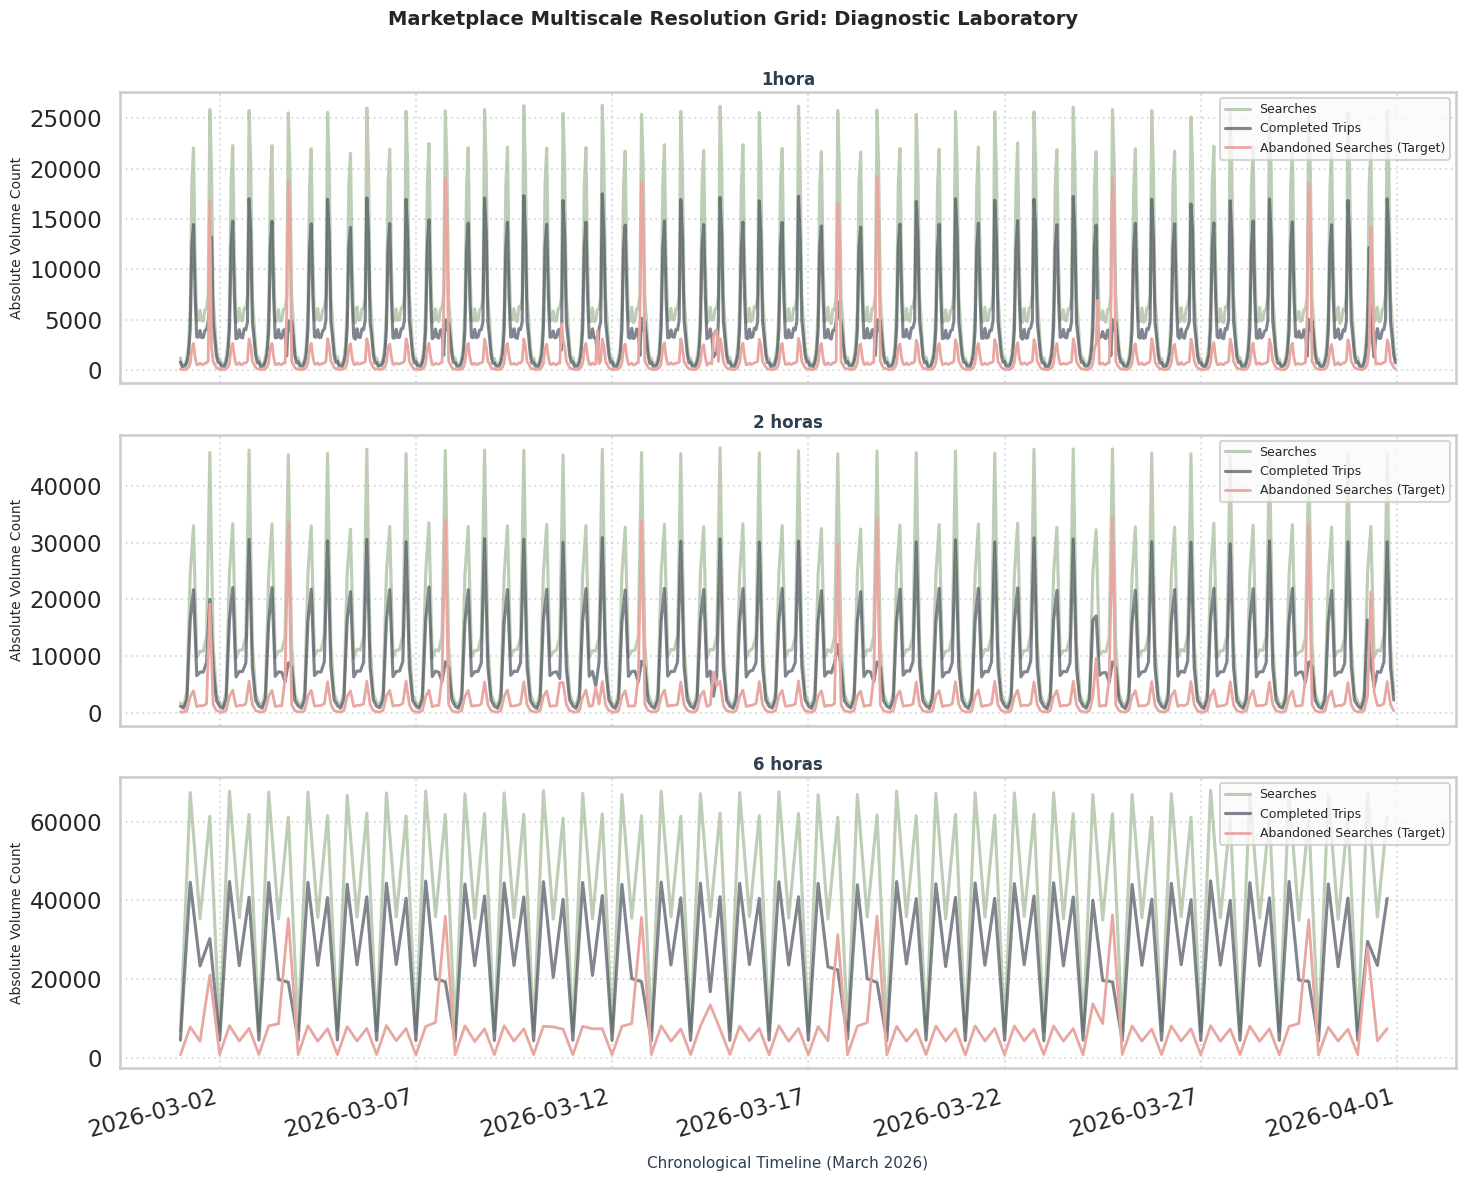

In [25]:
# ==============================================================================
# MODULE 4.4b: HIGH-FREQUENCY TEMPORAL RESAMPLING RESOLUTION MATRIX
# Objective: Dynamically resample the consolidated corridor series to 30-minute
# and 1-hour intervals, plotting them via Seaborn to determine the optimal modeling scale.
# ==============================================================================

color_searches = '#a2b997'  
color_completed = '#4c525d'  
color_abandoned = '#e8a7a1'

# 1. SETUP TEMPORAL DATAFRAME WITH DATETIME INDEX (Required for .resample)
df_resample_base = df_corridor_ts.set_index('timestamp_5min')

# 2. CANVAS GRID CONFIGURATION: 3 Stacked Rows sharing the exact same layout
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
axes_dict = {
    "1hora": (df_resample_base.resample('1H').sum(), ax1),
    "2 horas": (df_resample_base.resample('2H').sum(), ax2),
    "6 horas": (df_resample_base.resample('6H').sum(), ax3)
}

# 3. INTERACTIVE PLOTTING LOOP USING STRICT SEABORN PIPELINES
for title, (data_df, target_ax) in axes_dict.items():
    # Reset index locally to give Seaborn direct column access without mutating the loop array
    plot_df = data_df.reset_index().rename(columns={'index': 'timestamp_5min'})
    
    # Overlay the 3 continuous series
    sns.lineplot(data=plot_df, x='timestamp_5min', y='total_searches', 
                 label='Searches', color=color_searches, alpha=0.7, ax=target_ax)
    sns.lineplot(data=plot_df, x='timestamp_5min', y='total_completed_trips', 
                 label='Completed Trips', color=color_completed, alpha=0.7, ax=target_ax)
    sns.lineplot(data=plot_df, x='timestamp_5min', y='total_abandoned_searches', 
                 label='Abandoned Searches (Target)', color=color_abandoned, linewidth=2.0, ax=target_ax)
    
    # Formatting aesthetics per axes panel
    target_ax.set_title(title, fontsize=12, fontweight='bold', color='#2C3E50', pad=5)
    target_ax.set_ylabel('Absolute Volume Count', fontsize=10)
    target_ax.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
    target_ax.legend(loc='upper right', fontsize=9, frameon=True, facecolor='#FAFAFA')

# 4. CHRONOLOGICAL X-AXIS CALIBRATION (Applied strictly on the bottom matrix edge)
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=15)
ax3.set_xlabel('Chronological Timeline (March 2026)', fontsize=11, color='#2C3E50', labelpad=10)

plt.suptitle('Marketplace Multiscale Resolution Grid: Diagnostic Laboratory', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


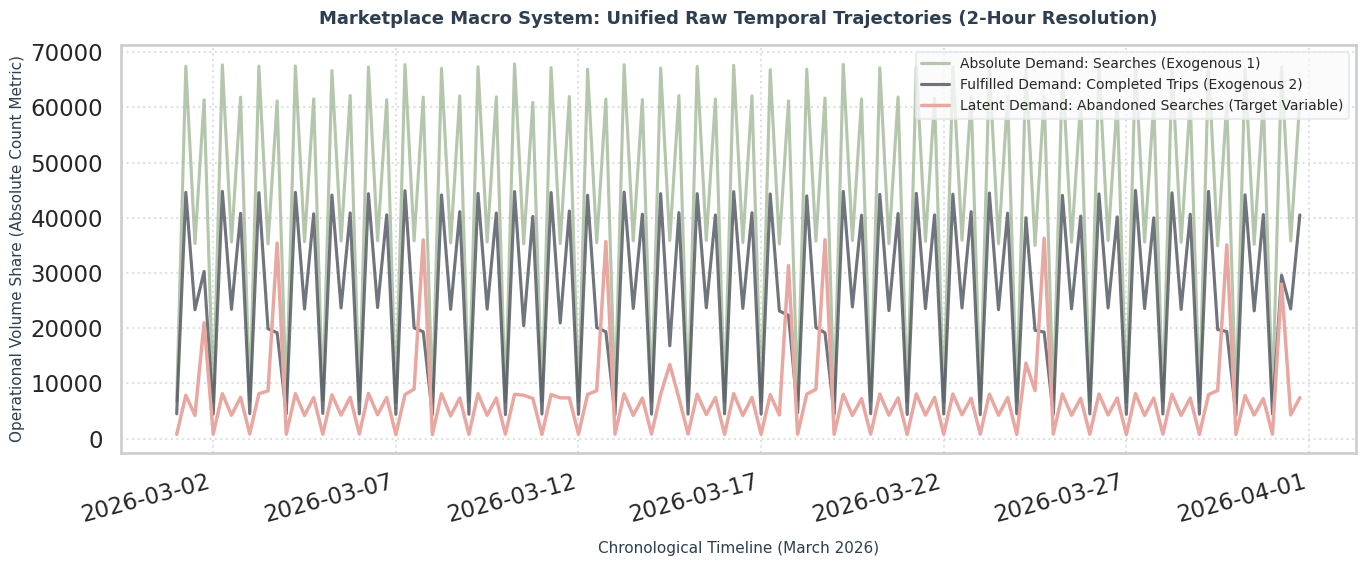

In [24]:
# ==============================================================================
# MODULE 4.4c: MACRO RESOLUTION EXPLORATION (2-HOUR AGGREGATE TRAJECTORY)
# Objective: Resample the consolidated corridor dataset into strict 2-hour 
# intervals, visualization via Seaborn to audit seasonal stability at a macro scale.
# ==============================================================================

import matplotlib.dates as mdates

# Enforce professional R-style muted aesthetics across the Seaborn instance
color_searches = '#a2b997'  
color_completed = '#4c525d'  
color_abandoned = '#e8a7a1'

# 1. SETUP TEMPORAL DATAFRAME WITH DATETIME INDEX
df_resample_2h = df_corridor_ts.set_index('timestamp_5min')

# 2. EXECUTE VECTOR DISCRETIZATION: 2-Hour resampling using modern string frequencies
# Note: '2h' groups exactly 24 intervals of 5 minutes into a single absolute sum
df_2h_macro = df_resample_2h.resample('6h').sum().reset_index().rename(columns={'index': 'timestamp_5min'})

# 3. CANVAS CONFIGURATION: Single global chart layout
fig, ax = plt.subplots(figsize=(14, 6))

# 4. PLOT ENGINE: Overlay the 3 macro continuous series using strict Seaborn mapping
sns.lineplot(data=df_2h_macro, x='timestamp_5min', y='total_searches', 
             label='Absolute Demand: Searches (Exogenous 1)', color=color_searches, alpha=0.8, ax=ax)
sns.lineplot(data=df_2h_macro, x='timestamp_5min', y='total_completed_trips', 
             label='Fulfilled Demand: Completed Trips (Exogenous 2)', color=color_completed, alpha=0.8, ax=ax)
sns.lineplot(data=df_2h_macro, x='timestamp_5min', y='total_abandoned_searches', 
             label='Latent Demand: Abandoned Searches (Target Variable)', color=color_abandoned, linewidth=2.5, ax=ax)

# 5. CHRONOLOGICAL X-AXIS CALIBRATION (Clean 5-day intervals maintained)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=15)

# 6. Corporate Visual Architecture Annotations
ax.set_title('Marketplace Macro System: Unified Raw Temporal Trajectories (2-Hour Resolution)', fontsize=13, fontweight='bold', color='#2C3E50', pad=15)
ax.set_xlabel('Chronological Timeline (March 2026)', fontsize=11, color='#2C3E50', labelpad=10)
ax.set_ylabel('Operational Volume Share (Absolute Count Metric)', fontsize=11, color='#2C3E50')

ax.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='#FAFAFA', edgecolor='#E2E8F0')

plt.tight_layout()
plt.show()
